# Notebook 1 — Exploração de Dados e Simulação de Drift

## Aula 3: Estratégias de Mitigação de Drift

### Objetivos
- Carregar e explorar o dataset sintético de **churn em telecomunicações**
- Analisar a dinâmica de drift entre os 3 períodos temporais (T0→T3)
- Visualizar **covariate shift**, **prior probability shift** e **concept drift**
- Identificar as features mais afetadas pela oferta disruptiva do concorrente

### Teoria-Chave (Documento 04 — Seção *Saiba Mais*)

> Mitigar *drift* não é um detalhe operacional; é uma decisão de arquitetura.  
> A mitigação deve ser entendida como um **ciclo de controle adaptativo**:  
> monitorar, diagnosticar, intervir e revalidar.  
> — Moreno-Torres et al. (2012); Quionero-Candela et al. (2009)

### Vídeo Relacionado
**Vídeo 1 — Estratégias de Mitigação de Data Drift** (15 min):  
Caso churn; abordagens reativas vs proativas; panorama de estratégias;  
linha do tempo de impacto do drift (T0 a T3).

In [1]:
# Imports
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Adiciona diretório raiz da aula ao path
sys.path.insert(0, str(Path.cwd().parent))

from src.data_preprocessing import DataPreprocessor

sns.set_theme(style="whitegrid")
%matplotlib inline

## 1. Geração / Carga do Dataset

O dataset simula o cenário descrito no documento acadêmico: uma operadora de  
telecomunicações enfrenta drift quando um concorrente lança uma oferta disruptiva.  

São 3 períodos:
- **Período 1 (T0–T1):** Regime estável pré-competição (~12% churn)
- **Período 2 (T1–T2):** Choque competitivo — drift abrupto (~28% churn)
- **Período 3 (T2–T3):** Adaptação gradual — drift incremental (~20% churn)

In [2]:
# Gera ou carrega o dataset
preprocessor = DataPreprocessor(seed=42)

data_path = Path.cwd().parent / "data" / "raw" / "dataset.csv"

if data_path.exists():
    df = preprocessor.load_data(str(data_path))
    print(f"Dataset carregado de {data_path}")
else:
    df = preprocessor.generate_and_save()
    print(f"Dataset gerado e salvo")

print(f"\nShape: {df.shape}")
df.head()

Dataset carregado de c:\Personal\Others\FIAP\POSTECH-DATA_DRIFT\9mlet-data-drift\03_estrategias_de_mitigacao_de_drift\data\raw\dataset.csv

Shape: (9000, 15)


,customer_id,tenure_months,monthly_charges,total_charges,data_usage_gb,call_duration_min,num_complaints,payment_delay_days,contract_type,has_premium_support,competitor_offer_exposure,customer_value_segment,period,timestamp_month,churn
0,1,7,94.07,671.09,9.05,355.1,1,5,0,1,0.4215,1,1,5,1
1,2,55,51.88,2846.04,7.54,239.2,0,3,2,0,0.8675,1,1,3,0
2,3,47,48.66,2411.05,11.15,424.8,0,2,1,0,0.4443,0,1,4,0
3,4,32,81.49,2527.32,5.60,355.9,0,7,1,0,0.8512,0,1,11,0
4,5,31,94.71,3080.91,8.36,612.4,0,3,2,0,0.3848,0,1,1,0


## 2. Visão Geral do Dataset

Verificamos tipos de dados, estatísticas descritivas e distribuição por período.

In [3]:
# Informações gerais
print("=" * 50)
print("Tipos de dados:")
print(df.dtypes)
print("\n" + "=" * 50)
print("Valores ausentes:")
print(df.isnull().sum())
print("\n" + "=" * 50)
print("Distribuição por período:")
print(df["period"].value_counts().sort_index())
print("\n" + "=" * 50)
print("Distribuição do target (churn):")
print(df["churn"].value_counts(normalize=True))

Tipos de dados:
customer_id                    int64
tenure_months                  int64
monthly_charges              float64
total_charges                float64
data_usage_gb                float64
call_duration_min            float64
num_complaints                 int64
payment_delay_days             int64
contract_type                  int64
has_premium_support            int64
competitor_offer_exposure    float64
customer_value_segment         int64
period                         int64
timestamp_month                int64
churn                          int64
dtype: object

Valores ausentes:
customer_id                  0
tenure_months                0
monthly_charges              0
total_charges                0
data_usage_gb                0
call_duration_min            0
num_complaints               0
payment_delay_days           0
contract_type                0
has_premium_support          0
competitor_offer_exposure    0
customer_value_segment       0
period                  

In [4]:
# Estatísticas descritivas por período
df.groupby("period").describe().T

period                       1            2            3
customer_id count  3000.000000  3000.000000  3000.000000
            mean   1500.500000  4500.500000  7500.500000
            std     866.169729   866.169729   866.169729
            min       1.000000  3001.000000  6001.000000
            25%     750.750000  3750.750000  6750.750000
...                        ...          ...          ...
churn       min       0.000000     0.000000     0.000000
            25%       0.000000     0.000000     0.000000
            50%       0.000000     0.000000     0.000000
            75%       0.000000     1.000000     0.000000
            max       1.000000     1.000000     1.000000

[112 rows x 3 columns]

## 3. Taxa de Churn por Período (Prior Probability Shift)

Conforme discutido na seção *Saiba Mais*, a taxa de churn salta de ~12% para ~28%  
quando a concorrência lança a oferta disruptiva. Isso é um exemplo clássico de  
**prior probability shift**: $P(Y=1)$ muda entre períodos.

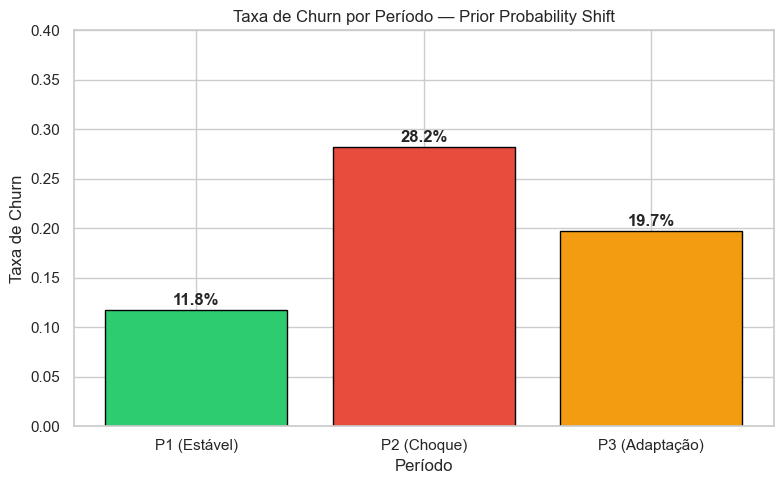

In [5]:
# Taxa de churn por período
churn_rates = df.groupby("period")["churn"].mean()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#2ecc71", "#e74c3c", "#f39c12"]
bars = ax.bar(churn_rates.index, churn_rates.values, color=colors, edgecolor="black")

for bar, rate in zip(bars, churn_rates.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{rate:.1%}", ha="center", fontsize=12, fontweight="bold")

ax.set_xlabel("Período")
ax.set_ylabel("Taxa de Churn")
ax.set_title("Taxa de Churn por Período — Prior Probability Shift")
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(["P1 (Estável)", "P2 (Choque)", "P3 (Adaptação)"])
ax.set_ylim(0, 0.40)
plt.tight_layout()
plt.savefig("../outputs/figures/churn_rate_by_period.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Covariate Shift — Distribuição de Features por Período

A seção *Saiba Mais* descreve que a oferta do concorrente alterou hábitos de consumo:  
`data_usage_gb` diminui no período 2 (clientes migrando reduzem uso), e  
`competitor_offer_exposure` aumenta significativamente.

> "O modelo de churn foi treinado em uma fase de relativa estabilidade  
> competitiva e aprendeu correlações coerentes com aquele período."  
> — Documento 04, Seção Saiba Mais

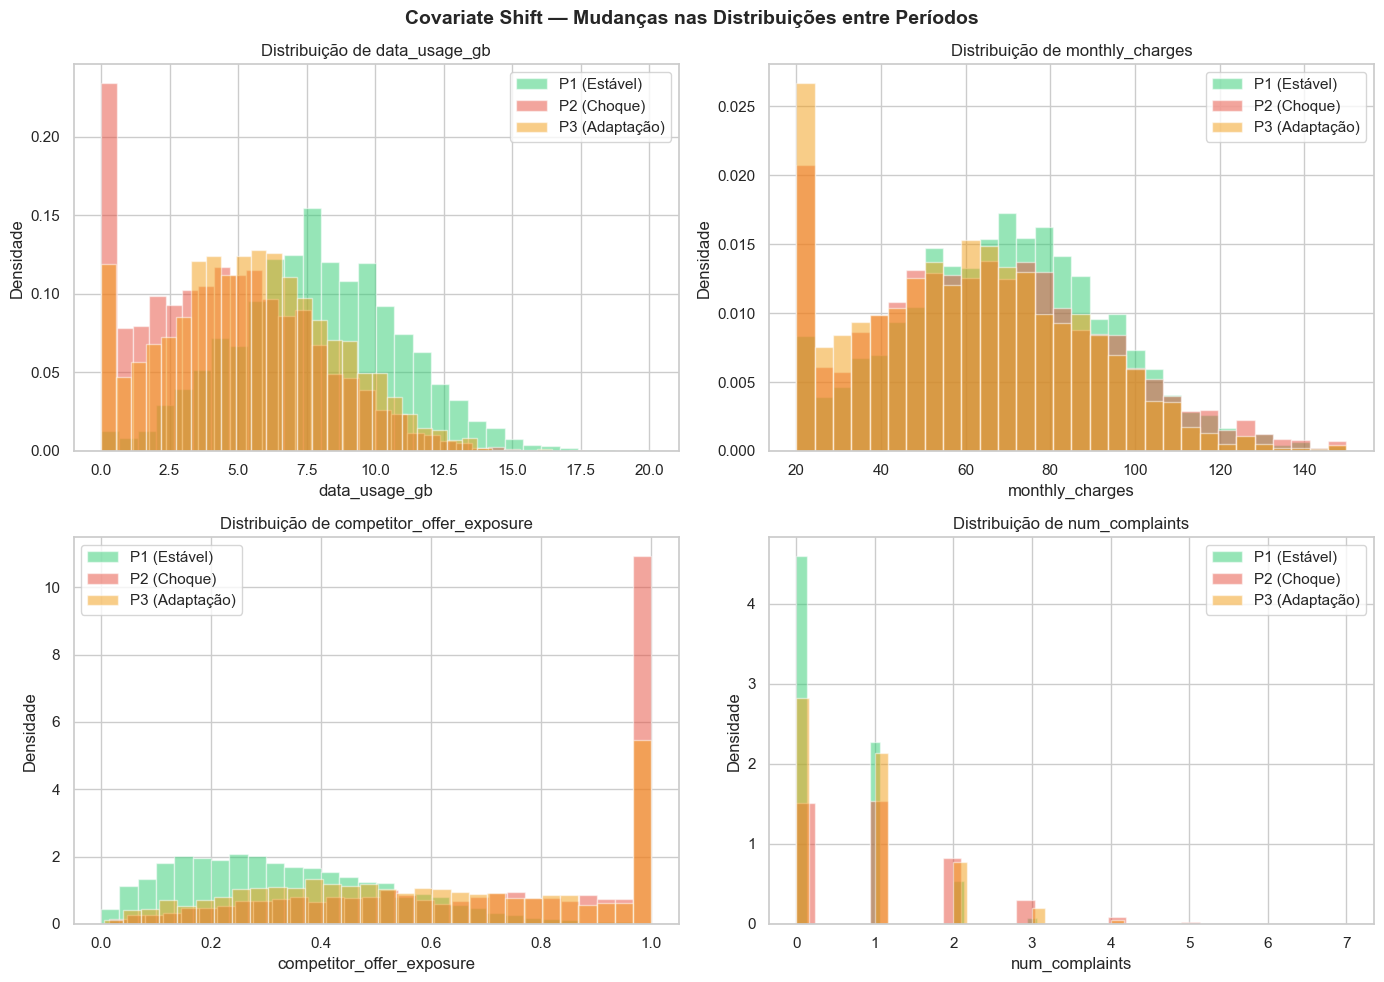

In [6]:
# Distribuições de features-chave por período
key_features = ["data_usage_gb", "monthly_charges", "competitor_offer_exposure", "num_complaints"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
period_labels = {1: "P1 (Estável)", 2: "P2 (Choque)", 3: "P3 (Adaptação)"}
period_colors = {1: "#2ecc71", 2: "#e74c3c", 3: "#f39c12"}

for ax, feature in zip(axes.flat, key_features):
    for period in [1, 2, 3]:
        data = df[df["period"] == period][feature]
        ax.hist(data, bins=30, alpha=0.5, label=period_labels[period],
                color=period_colors[period], density=True)
    ax.set_title(f"Distribuição de {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Densidade")
    ax.legend()

fig.suptitle("Covariate Shift — Mudanças nas Distribuições entre Períodos",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/covariate_shift_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Estatísticas por Período — Quantificando o Deslocamento

Calculamos média e desvio padrão de features-chave para cada período,  
permitindo uma visão numérica do drift.

In [7]:
# Estatísticas por período para features-chave
stats_features = ["data_usage_gb", "monthly_charges", "num_complaints",
                  "competitor_offer_exposure", "payment_delay_days"]

stats_df = df.groupby("period")[stats_features].agg(["mean", "std"])
stats_df.columns = [f"{col[0]}_{col[1]}" for col in stats_df.columns]
stats_df.round(3)

,data_usage_gb_mean,data_usage_gb_std,monthly_charges_mean,monthly_charges_std,num_complaints_mean,num_complaints_std,competitor_offer_exposure_mean,competitor_offer_exposure_std,payment_delay_days_mean,payment_delay_days_std
period,,,,,,,,,,
1,7.909,3.021,69.746,24.545,0.486,0.695,0.332,0.190,6.415,6.962
2,4.541,3.178,64.959,27.873,1.063,1.049,0.713,0.291,8.362,8.949
3,5.460,3.074,60.520,26.421,0.752,0.871,0.592,0.288,10.395,10.988


## 6. Concept Drift — Relação Feature-Target Muda

Conforme discutido no documento acadêmico, no **concept drift** a relação  
$P(Y|X)$ muda. No período 2, a correlação entre `monthly_charges` e `churn`  
se inverte parcialmente: clientes de planos mais caros também passam a cancelar.

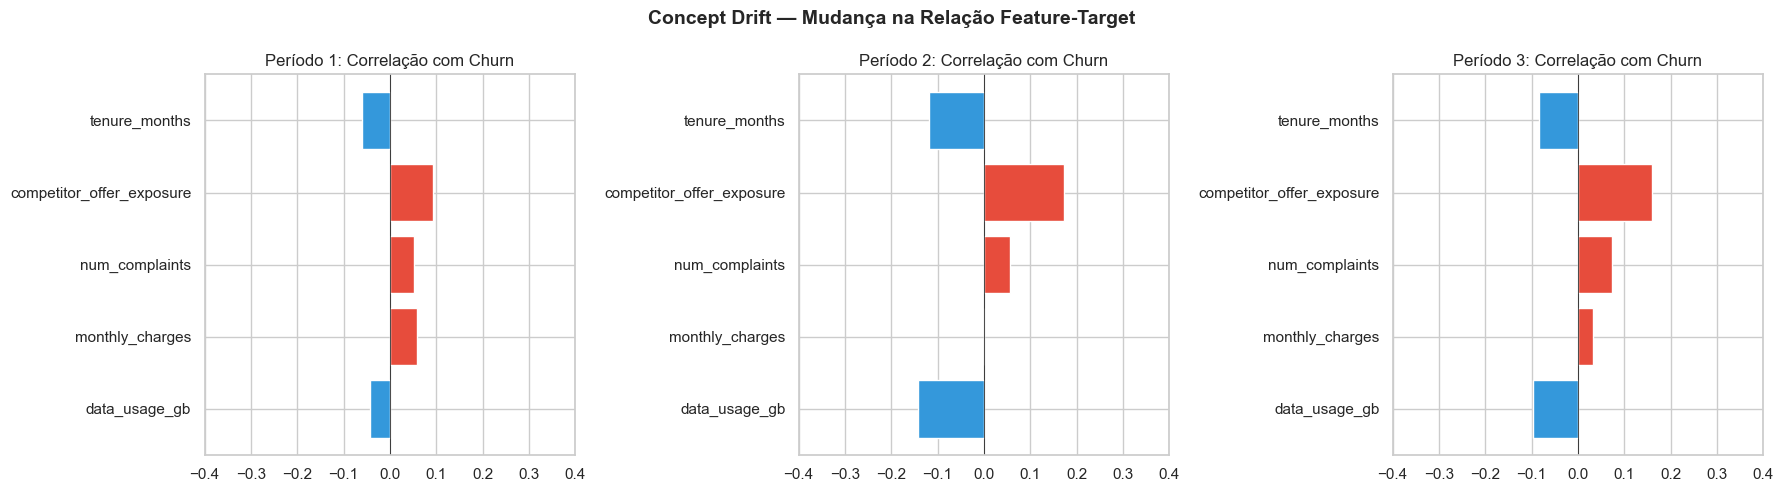

In [8]:
# Correlação feature-target por período
corr_features = ["data_usage_gb", "monthly_charges", "num_complaints",
                 "competitor_offer_exposure", "tenure_months"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, period in enumerate([1, 2, 3]):
    df_p = df[df["period"] == period]
    corr = df_p[corr_features + ["churn"]].corr()["churn"].drop("churn")
    colors = ["#e74c3c" if v > 0 else "#3498db" for v in corr.values]
    axes[idx].barh(corr.index, corr.values, color=colors)
    axes[idx].set_title(f"Período {period}: Correlação com Churn")
    axes[idx].set_xlim(-0.4, 0.4)
    axes[idx].axvline(0, color="black", linewidth=0.5)

fig.suptitle("Concept Drift — Mudança na Relação Feature-Target",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/concept_drift_correlations.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Heatmap de Correlações por Período

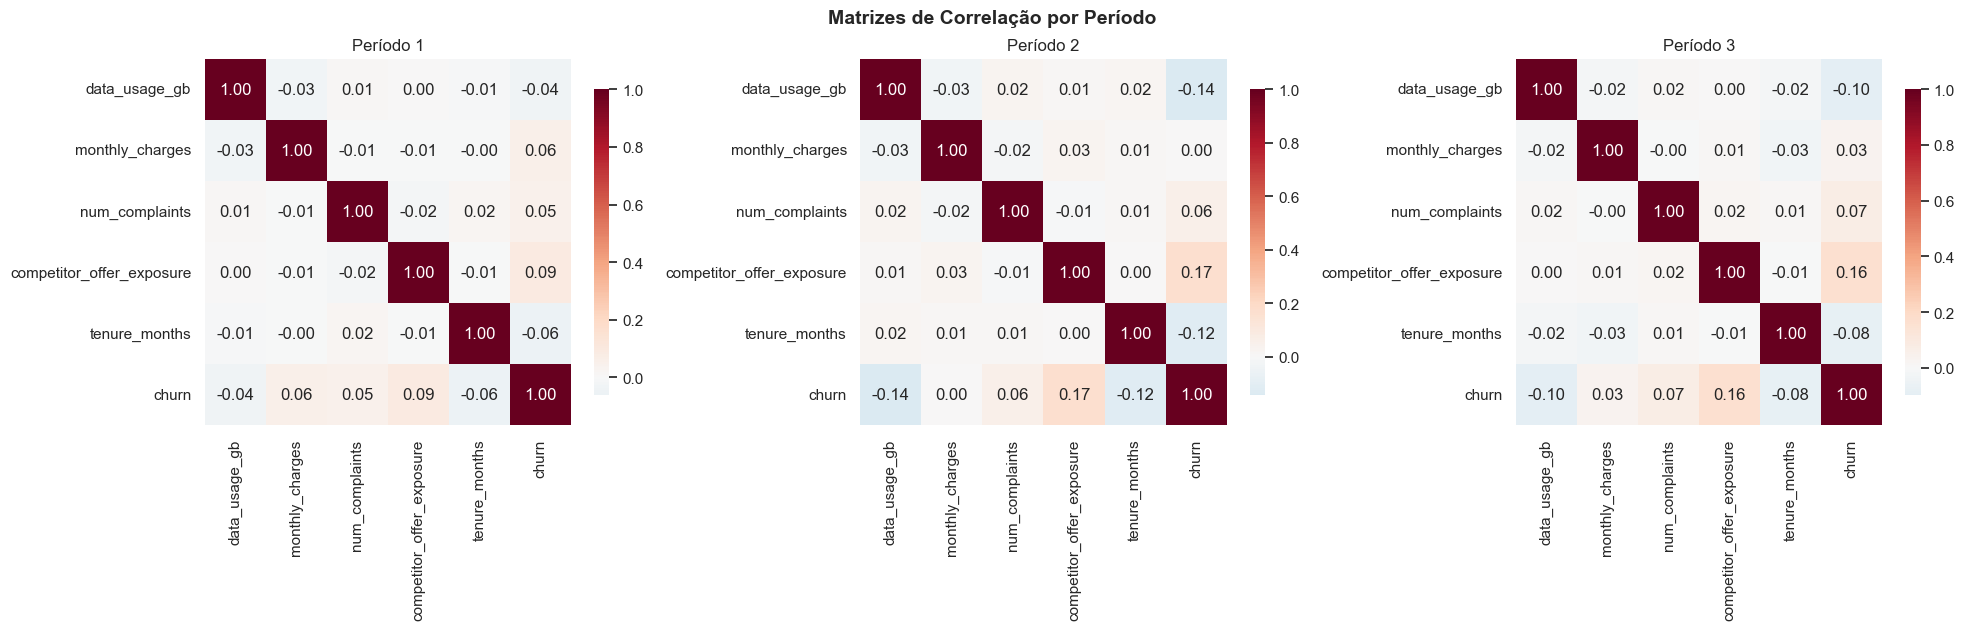

In [9]:
# Heatmap de correlação por período
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for idx, period in enumerate([1, 2, 3]):
    df_p = df[df["period"] == period][corr_features + ["churn"]]
    sns.heatmap(df_p.corr(), annot=True, fmt=".2f", cmap="RdBu_r",
                center=0, ax=axes[idx], square=True, cbar_kws={"shrink": 0.8})
    axes[idx].set_title(f"Período {period}")

fig.suptitle("Matrizes de Correlação por Período", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/correlation_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Análise de Segmentos de Valor

Conforme discutido na seção *Saiba Mais*, a validação segmentada é essencial:  
> "Uma melhora global de acurácia pode esconder uma piora justamente nos  
> clientes de maior valor, onde a perda econômica é mais alta."  
> — Provost & Fawcett (2013)

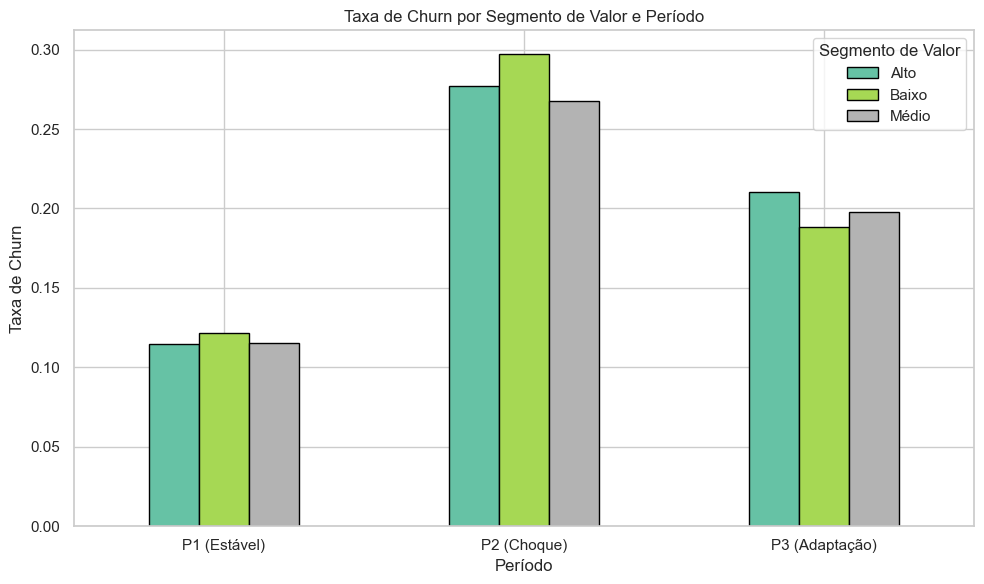

In [10]:
# Churn por segmento de valor e período
segment_labels = {0: "Baixo", 1: "Médio", 2: "Alto"}
df["segment_label"] = df["customer_value_segment"].map(segment_labels)

churn_by_segment = df.groupby(["period", "segment_label"])["churn"].mean().unstack()

fig, ax = plt.subplots(figsize=(10, 6))
churn_by_segment.plot(kind="bar", ax=ax, colormap="Set2", edgecolor="black")
ax.set_xlabel("Período")
ax.set_ylabel("Taxa de Churn")
ax.set_title("Taxa de Churn por Segmento de Valor e Período")
ax.set_xticklabels(["P1 (Estável)", "P2 (Choque)", "P3 (Adaptação)"], rotation=0)
ax.legend(title="Segmento de Valor")
plt.tight_layout()
plt.savefig("../outputs/figures/churn_by_segment.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Boxplots Temporais — Evolução de Features

Visualizamos como cada feature-chave evolui ao longo do tempo,  
reforçando a **linha do tempo de impacto** (T0 a T3) discutida no Vídeo 1.

C:\Users\diogomiyake\AppData\Local\Temp\ipykernel_13232\2335639562.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="period", y=feature, ax=ax, palette=colors)
C:\Users\diogomiyake\AppData\Local\Temp\ipykernel_13232\2335639562.py:4: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  sns.boxplot(data=df, x="period", y=feature, ax=ax, palette=colors)
C:\Users\diogomiyake\AppData\Local\Temp\ipykernel_13232\2335639562.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="period", y=feature, ax=ax, palette=colors)
C:\Users\diogomiyake\AppData\Local\Temp\ipykernel_13232\2335639562.py:4: UserWarning: The palette list has more va

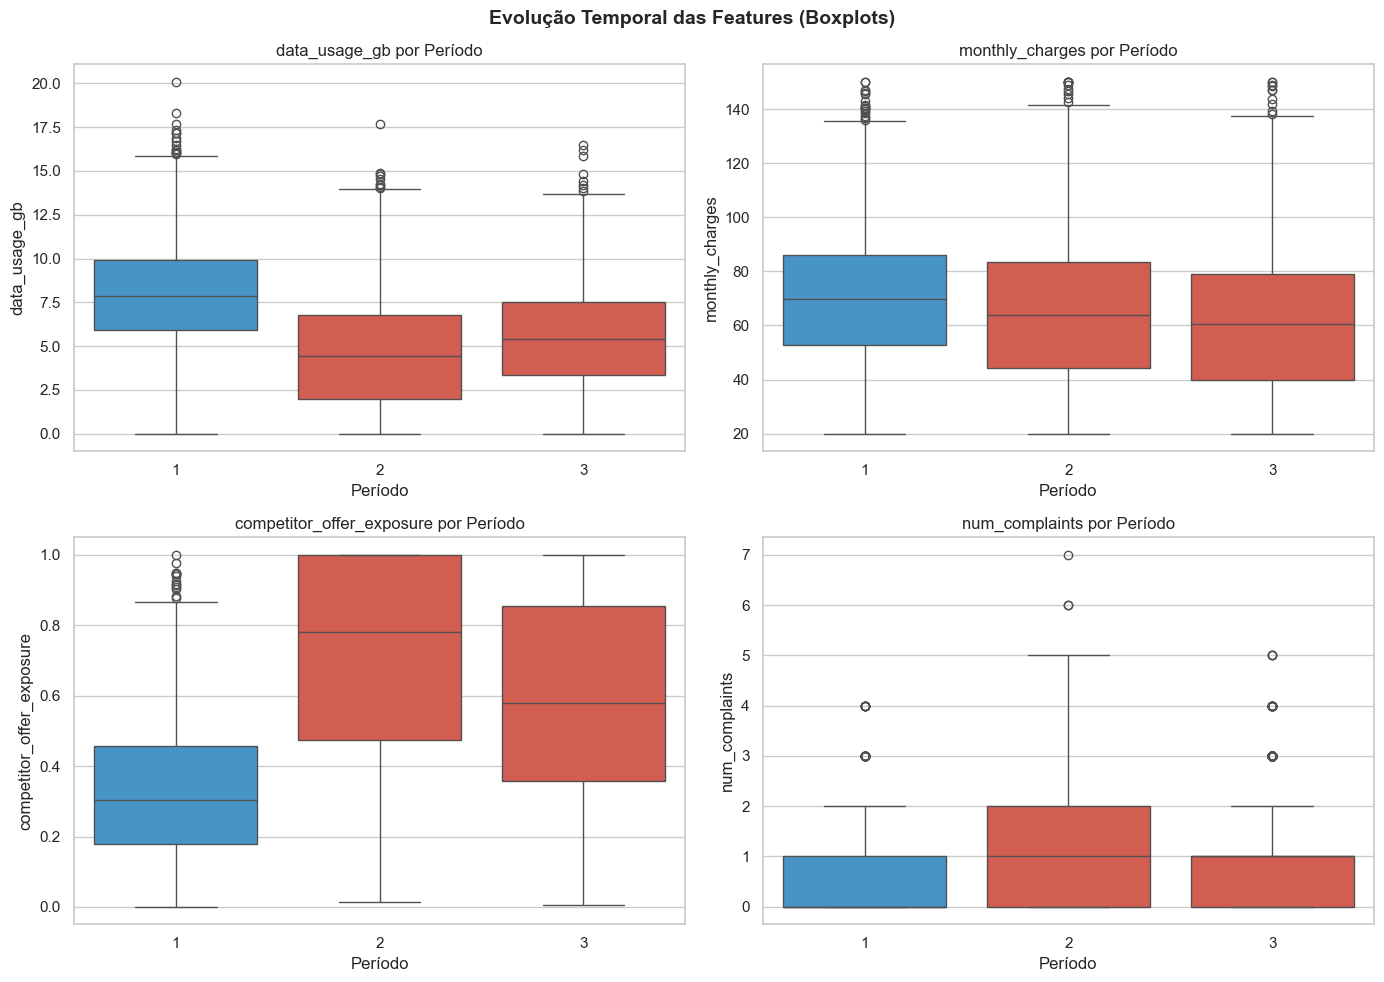

In [11]:
# Boxplots de features por período
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, feature in zip(axes.flat, key_features):
    sns.boxplot(data=df, x="period", y=feature, ax=ax, palette=colors)
    ax.set_title(f"{feature} por Período")
    ax.set_xlabel("Período")

fig.suptitle("Evolução Temporal das Features (Boxplots)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/boxplots_by_period.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Tabela-Resumo das Estratégias de Mitigação

Replicamos a **Tabela 1** do documento acadêmico para referência nos  
próximos notebooks, onde cada estratégia será implementada.

In [12]:
# Tabela de estratégias (Tabela 1 do documento acadêmico)
strategies = pd.DataFrame({
    "Estratégia": [
        "Re-treinamento sob demanda",
        "Aprendizado contínuo",
        "Ensemble adaptativo",
        "Ajuste de limiar",
        "Tratamento de outliers",
        "Regras de negócio",
    ],
    "Natureza": ["Reativa", "Proativa", "Proativa", "Reativa", "Híbrida", "Reativa"],
    "Tempo de Resposta": ["Dias", "Segundos a dias", "Minutos a dias", "Minutos", "Minutos a horas", "Imediata"],
    "Risco Principal": [
        "Reagir tarde demais",
        "Esquecimento de padrões úteis",
        "Complexidade operacional",
        "Queda de precisão",
        "Descartar sinal legítimo",
        "Baixa escalabilidade",
    ],
})
strategies

,Estratégia,Natureza,Tempo de Resposta,Risco Principal
0,Re-treinamento sob demanda,Reativa,Dias,Reagir tarde demais
1,Aprendizado contínuo,Proativa,Segundos a dias,Esquecimento de padrões úteis
2,Ensemble adaptativo,Proativa,Minutos a dias,Complexidade operacional
3,Ajuste de limiar,Reativa,Minutos,Queda de precisão
4,Tratamento de outliers,Híbrida,Minutos a horas,Descartar sinal legítimo
5,Regras de negócio,Reativa,Imediata,Baixa escalabilidade


## Resumo

Neste notebook exploramos o dataset de churn telecom com drift simulado e observamos:

1. **Prior probability shift**: a taxa de churn salta de ~12% (P1) para ~28% (P2)
2. **Covariate shift**: `data_usage_gb` diminui e `competitor_offer_exposure` aumenta
3. **Concept drift**: a correlação entre `monthly_charges` e churn se inverte parcialmente
4. A análise segmentada revela impactos diferenciados por segmento de valor

### Próximo Notebook
No **Notebook 02 — Treinamento e Re-treinamento**, implementaremos:
- Modelo baseline treinado no período estável
- Re-treinamento com janela deslizante
- Estratégia champion/challenger
- Aprendizado online com ADWIN (River)